# 第 8 章 · MLPClassifier

[章节网页](../ch8.html)

## 运行内容

- 调用 sklearn MLPClassifier
- 输出预测概率
- 绘制网络结构

## 0. 环境与数据

In [1]:
# 准备运行时：本 notebook 内嵌所需源码和数据，不依赖在线封装文件。
import importlib.util
import subprocess
import sys
from pathlib import Path

INLINE_RUNTIME_FILES = {
  "labs/ch08/neural.py": "\"\"\"Chapter 8 neural demos — pedagogical API.\"\"\"\n\nfrom __future__ import annotations\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nfrom sklearn.neural_network import MLPClassifier\n\nX = np.array([6.2, 0.8])\nH = np.array([0.71, 0.45])\nY_HAT = 0.82\nW1 = np.array([[0.3, 0.2], [0.1, 0.4]])\nW2 = np.array([0.5, 0.3])\nB1 = np.array([0.0, 0.0])\nB2 = 0.0\n\nMLP_X = np.array(\n    [\n        [5.8, 0.2],\n        [6.1, 0.4],\n        [6.5, 0.7],\n        [7.0, 1.1],\n        [4.8, 1.8],\n        [5.1, 2.1],\n        [5.6, 2.5],\n        [6.0, 2.8],\n    ],\n    dtype=float,\n)\nMLP_Y = np.array([1, 1, 1, 1, 0, 0, 0, 0], dtype=int)\n\n\ndef mlp_dataset() -> tuple[np.ndarray, np.ndarray]:\n    \"\"\"Return a tiny binary dataset for sklearn MLPClassifier.\"\"\"\n    return MLP_X.copy(), MLP_Y.copy()\n\n\ndef mlp_result_table(model: MLPClassifier, x: np.ndarray, y: np.ndarray) -> pd.DataFrame:\n    \"\"\"Show predictions from a fitted sklearn MLPClassifier or pipeline.\"\"\"\n    prob = model.predict_proba(x)[:, 1]\n    pred = model.predict(x)\n    return pd.DataFrame(\n        {\n            \"血糖\": x[:, 0],\n            \"运动\": x[:, 1],\n            \"真实标签\": y,\n            \"预测标签\": pred,\n            \"风险概率\": np.round(prob, 3),\n        }\n    )\n\n\ndef relu(z: np.ndarray) -> np.ndarray:\n    return np.maximum(0, z)\n\n\ndef sigmoid(z: float) -> float:\n    return 1 / (1 + np.exp(-z))\n\n\ndef forward_trace() -> pd.DataFrame:\n    z1 = W1 @ X + B1\n    h = relu(z1)\n    y = sigmoid(float(W2 @ h + B2))\n    return pd.DataFrame(\n        [\n            {\"阶段\": \"输入 x\", \"值\": str(X.round(2))},\n            {\"阶段\": \"z1=W1x+b1\", \"值\": str(z1.round(2))},\n            {\"阶段\": \"h=ReLU(z1)\", \"值\": str(h.round(2))},\n            {\"阶段\": \"ŷ=σ(W2h+b2)\", \"值\": f\"{y:.2f} (网页 {Y_HAT})\"},\n        ]\n    )\n\n\ndef forward_demo() -> None:\n    print(forward_trace().to_string(index=False))\n\n\ndef backward_demo() -> None:\n    y = Y_HAT\n    delta_out = y * (1 - y) * (y - 1)\n    delta_h = (W2 * delta_out) * (H > 0)\n    print(f\"δ_out={delta_out:.3f} (网页 0.036)\")\n    print(f\"δ_h={delta_h.round(3)} (网页 [0.018, 0.011])\")\n\n\ndef plot_mlp_flow() -> None:\n    fig, ax = plt.subplots(figsize=(8, 3))\n    layers = [\"x1,x2\", \"h1,h2\", \"y_hat\"]\n    xs = [0, 1, 2]\n    ax.scatter(xs, [0, 0, 0], s=200, c=[\"#3498db\", \"#0d6b62\", \"#e67e22\"])\n    for i in range(len(xs) - 1):\n        ax.annotate(\"\", xy=(xs[i + 1], 0), xytext=(xs[i], 0), arrowprops=dict(arrowstyle=\"->\", lw=2))\n    ax.set_xticks(xs)\n    ax.set_xticklabels(layers)\n    ax.set_yticks([])\n    ax.set_title(\"MLP forward pass\")\n    plt.tight_layout()\n    plt.show()\n\n\ndef transe_demo() -> None:\n    d_pos, d_neg = 0.31, 2.08\n    print(f\"正例 (鲁迅,创作,呐喊) d+={d_pos:.2f}\")\n    print(f\"负例尾「红楼梦」 d-={d_neg:.2f}\")\n    print(f\"margin loss: max(0, {d_pos:.2f}+1-{d_neg:.2f})={max(0, d_pos+1-d_neg):.2f}\")\n\n\ndef plot_transe() -> None:\n    fig, ax = plt.subplots()\n    h = np.array([0.0, 0.0])\n    r = np.array([1.0, 0.5])\n    t_pos = h + r\n    t_neg = np.array([2.5, 1.8])\n    ax.scatter(*h, s=120, label=\"h\")\n    ax.scatter(*t_pos, s=120, label=\"t+\")\n    ax.scatter(*t_neg, s=120, label=\"t-\")\n    ax.arrow(h[0], h[1], r[0], r[1], head_width=0.08, color=\"#0d6b62\", length_includes_head=True)\n    ax.set_title(\"TransE: h + r ~ t\")\n    ax.legend()\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef softmax(x: np.ndarray) -> np.ndarray:\n    e = np.exp(x - x.max())\n    return e / e.sum()\n\n\ndef attention_demo() -> None:\n    tokens = [\"鲁迅\", \"写\", \"日记\"]\n    scores = np.array([0.4, 2.1, 0.3])\n    w = softmax(scores)\n    target = np.array([0.05, 0.80, 0.15])\n    print(\"tokens:\", tokens)\n    for t, s, a, e in zip(tokens, scores, w, target):\n        print(f\"  {t}: score={s:.1f} α={a:.2f} (网页 {e:.2f})\")\n\n\ndef plot_attention() -> None:\n    tokens = [\"t0\", \"t1\", \"t2\"]\n    weights = np.array([0.05, 0.80, 0.15])\n    fig, ax = plt.subplots()\n    ax.bar(tokens, weights, color=\"#0d6b62\")\n    ax.set_ylim(0, 1)\n    ax.set_title(\"Cross-attention weights\")\n    ax.set_ylabel(\"alpha (softmax)\")\n    plt.tight_layout()\n    plt.show()\n",
  "labs/common/campus_graph.json": "{\n  \"goal\": \"c1\",\n  \"start\": \"x\",\n  \"nodes\": {\n    \"x\": { \"name\": \"校门口\", \"h\": 7 },\n    \"c2\": { \"name\": \"超市\", \"h\": 1 },\n    \"j\": { \"name\": \"教学楼\", \"h\": 4 },\n    \"s2\": { \"name\": \"实验楼\", \"h\": 4 },\n    \"s1\": { \"name\": \"食堂\", \"h\": 3 },\n    \"t\": { \"name\": \"图书馆\", \"h\": 2 },\n    \"c1\": { \"name\": \"操场\", \"h\": 0 }\n  },\n  \"edges\": [\n    { \"from\": \"x\", \"to\": \"c2\", \"cost\": 7 },\n    { \"from\": \"x\", \"to\": \"j\", \"cost\": 2 },\n    { \"from\": \"x\", \"to\": \"s1\", \"cost\": 2 },\n    { \"from\": \"j\", \"to\": \"s2\", \"cost\": 4 },\n    { \"from\": \"s2\", \"to\": \"s1\", \"cost\": 1 },\n    { \"from\": \"s1\", \"to\": \"t\", \"cost\": 3 },\n    { \"from\": \"s1\", \"to\": \"c1\", \"cost\": 6 },\n    { \"from\": \"t\", \"to\": \"c1\", \"cost\": 2 }\n  ],\n  \"expected\": {\n    \"dfs\": { \"path\": [\"x\", \"j\", \"s2\", \"s1\", \"c1\"], \"steps\": 4, \"cost\": 13 },\n    \"bfs\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"ucs\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 },\n    \"greedy\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"astar\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 }\n  }\n}\n",
  "labs/common/ch6_kg.json": "{\n  \"nodes\": [\"鲁迅\", \"狂人日记\", \"呐喊\", \"文学周报社\", \"茅盾文学奖\", \"莫言\", \"蛙\", \"红高粱\", \"典藏\", \"电影\", \"金熊奖\"],\n  \"edges\": [\n    [\"鲁迅\", \"创作\", \"狂人日记\"],\n    [\"鲁迅\", \"创作\", \"呐喊\"],\n    [\"狂人日记\", \"发表于\", \"文学周报社\"],\n    [\"呐喊\", \"发表于\", \"文学周报社\"],\n    [\"狂人日记\", \"获得\", \"茅盾文学奖\"],\n    [\"莫言\", \"创作\", \"蛙\"],\n    [\"莫言\", \"创作\", \"红高粱\"],\n    [\"蛙\", \"获得\", \"茅盾文学奖\"],\n    [\"红高粱\", \"入选\", \"典藏\"],\n    [\"红高粱\", \"改编\", \"电影\"],\n    [\"电影\", \"获得\", \"金熊奖\"]\n  ],\n  \"query\": {\n    \"pattern\": [\"鲁迅\", \"创作\", \"?X\", \"?X\", \"发表于\", \"?Y\"],\n    \"answer_y\": \"文学周报社\"\n  },\n  \"path_scores\": {\n    \"蛙→茅盾文学奖\": 3,\n    \"红高粱→典藏\": 2,\n    \"红高粱→电影→金熊奖\": 3\n  }\n}\n",
  "labs/common/ch6_rules.json": "{\n  \"facts\": [\"人(苏格拉底)\"],\n  \"rules\": [\n    { \"id\": \"R1\", \"if\": [\"人(X)\"], \"then\": \"会死(X)\" },\n    { \"id\": \"R2\", \"if\": [\"会死(X)\"], \"then\": \"终有一死(X)\" }\n  ],\n  \"goal\": \"终有一死(苏格拉底)\"\n}\n",
  "labs/common/codelens.py": "\"\"\"CodeLens-style execution frames — print every variable change.\"\"\"\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass, field\nfrom typing import Any\n\n\n@dataclass\nclass Frame:\n    step: int\n    line: str\n    narrative: str\n    state: dict[str, Any] = field(default_factory=dict)\n\n    def print(self) -> None:\n        print(f\"── Step {self.step} ── {self.narrative}\")\n        print(f\"   执行: {self.line}\")\n        for k, v in self.state.items():\n            print(f\"   {k} = {v!r}\")\n\n\ndef print_frames(frames: list[Frame], start: int = 0, stop: int | None = None) -> None:\n    for f in frames[start:stop]:\n        f.print()\n        print()\n\n\ndef frames_to_table(frames: list[Frame], keys: list[str]) -> \"pd.DataFrame\":\n    import pandas as pd\n\n    rows = []\n    for f in frames:\n        row = {\"步\": f.step, \"说明\": f.narrative}\n        for k in keys:\n            row[k] = f.state.get(k, \"\")\n        rows.append(row)\n    return pd.DataFrame(rows)\n",
  "labs/common/luxun_bpe.json": "{\n  \"corpus_hint\": \"鲁迅 写 了 狂人 日记\",\n  \"initial_tokens\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日\", \"记\"],\n  \"merges\": [\n    { \"pair\": [\"日\", \"记\"], \"count\": 12, \"result\": \"日记\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日记\"] },\n    { \"pair\": [\"狂\", \"人\"], \"count\": 8, \"result\": \"狂人\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂人\", \"日记\"] },\n    { \"pair\": [\"鲁\", \"迅\"], \"count\": 6, \"result\": \"鲁迅\", \"tokens_after\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"] }\n  ],\n  \"final_tokens\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"]\n}\n",
  "labs/common/mpl_setup.py": "\"\"\"Matplotlib font setup for notebook figures.\"\"\"\n\nfrom __future__ import annotations\n\nimport logging\nimport warnings\nfrom pathlib import Path\n\nimport matplotlib as mpl\nimport matplotlib.font_manager as fm\n\n# Prefer one fixed CJK face in rendered site; keep local fallbacks for downloaded notebooks.\nCJK_FONT = \"Noto Sans CJK SC\"\n\n_FONT_PATHS = [\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc\",\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc\",\n    \"/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc\",\n    \"/System/Library/Fonts/PingFang.ttc\",\n    \"/System/Library/Fonts/STHeiti Light.ttc\",\n    \"/Library/Fonts/Arial Unicode.ttf\",\n]\n\n_CJK_NAMES = [\n    CJK_FONT,\n    \"Noto Sans SC\",\n    \"Source Han Sans SC\",\n    \"PingFang SC\",\n    \"Heiti SC\",\n    \"STHeiti\",\n    \"Arial Unicode MS\",\n    \"WenQuanYi Micro Hei\",\n]\n\n_CONFIGURED = False\n\n\ndef _register_font_files() -> str | None:\n    registered: list[str] = []\n    for path in _FONT_PATHS:\n        p = Path(path)\n        if not p.is_file():\n            continue\n        try:\n            fm.fontManager.addfont(str(p))\n            prop = fm.FontProperties(fname=str(p))\n            name = prop.get_name()\n            if name and name not in registered:\n                registered.append(name)\n        except Exception:\n            continue\n    return registered[0] if registered else None\n\n\ndef _find_cjk_font() -> str | None:\n    from_file = _register_font_files()\n    available = {f.name for f in fm.fontManager.ttflist}\n    if CJK_FONT in available:\n        return CJK_FONT\n    if from_file:\n        return from_file\n    for name in _CJK_NAMES:\n        if name in available:\n            return name\n    return None\n\n\ndef configure_matplotlib() -> None:\n    \"\"\"Notebook 首个绘图 cell 前调用一次。\"\"\"\n    global _CONFIGURED\n    if _CONFIGURED:\n        return\n    _CONFIGURED = True\n\n    logging.getLogger(\"matplotlib.font_manager\").setLevel(logging.ERROR)\n    warnings.filterwarnings(\"ignore\", message=\".*Glyph.*missing from font.*\")\n    warnings.filterwarnings(\"ignore\", message=\".*findfont.*\")\n\n    name = _find_cjk_font()\n    if name:\n        mpl.rcParams[\"font.sans-serif\"] = [name, \"DejaVu Sans\", \"sans-serif\"]\n        mpl.rcParams[\"font.family\"] = \"sans-serif\"\n    else:\n        mpl.rcParams[\"font.sans-serif\"] = [\"DejaVu Sans\", \"sans-serif\"]\n    mpl.rcParams[\"axes.unicode_minus\"] = False\n    mpl.rcParams[\"figure.dpi\"] = 100\n    mpl.rcParams[\"mathtext.default\"] = \"regular\"\n\n\ndef ascii_plot(text: str) -> str:\n    \"\"\"把常见数学符号换成 DejaVu 可显示的 ASCII（用于轴标签/GIF）。\"\"\"\n    repl = {\n        \"α\": \"alpha\",\n        \"β\": \"beta\",\n        \"γ\": \"gamma\",\n        \"δ\": \"delta\",\n        \"ε\": \"eps\",\n        \"σ\": \"sigma\",\n        \"ŷ\": \"y_hat\",\n        \"₁\": \"1\",\n        \"₂\": \"2\",\n        \"₃\": \"3\",\n        \"→\": \"->\",\n    }\n    out = text\n    for k, v in repl.items():\n        out = out.replace(k, v)\n    return out\n",
  "labs/common/notebook_helpers.py": "\"\"\"Shared helpers for pedagogical notebooks.\"\"\"\n\nfrom __future__ import annotations\n\nimport textwrap\nfrom pathlib import Path\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\n\n# Keep helper plots aligned with the rendered notebook font.\nplt.rcParams.update(\n    {\n        \"figure.figsize\": (7.5, 4.2),\n        \"font.size\": 11,\n        \"axes.unicode_minus\": False,\n        \"font.family\": \"sans-serif\",\n        \"font.sans-serif\": [\"Noto Sans CJK SC\", \"DejaVu Sans\", \"sans-serif\"],\n    }\n)\n\n\ndef repo_root() -> Path:\n    cwd = Path.cwd()\n    if (cwd / \"labs\").exists():\n        return cwd\n    if (cwd.parent / \"labs\").exists():\n        return cwd.parent\n    return cwd\n\n\nBOOTSTRAP = textwrap.dedent(\n    \"\"\"\n    import sys\n    from pathlib import Path\n    ROOT = Path.cwd()\n    if not (ROOT / \"labs\").exists() and (ROOT.parent / \"labs\").exists():\n        ROOT = ROOT.parent\n    if str(ROOT) not in sys.path:\n        sys.path.insert(0, str(ROOT))\n    \"\"\"\n).strip()\n\n\ndef bootstrap_code(extra: str = \"\") -> str:\n    return BOOTSTRAP + (\"\\n\" + extra.strip() if extra.strip() else \"\")\n\n\ndef show_df(df: pd.DataFrame, title: str = \"\") -> None:\n    if title:\n        print(title)\n    print(df.to_string(index=False))\n\n\ndef plot_line_series(\n    xs: list,\n    ys: list,\n    *,\n    title: str,\n    xlabel: str = \"\",\n    ylabel: str = \"\",\n    markers: bool = True,\n) -> None:\n    fig, ax = plt.subplots()\n    ax.plot(xs, ys, marker=\"o\" if markers else None, linewidth=2)\n    ax.set_title(title)\n    if xlabel:\n        ax.set_xlabel(xlabel)\n    if ylabel:\n        ax.set_ylabel(ylabel)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef plot_scatter_labeled(\n    points: np.ndarray,\n    labels: np.ndarray | None,\n    *,\n    title: str,\n    label_names: dict[int, str] | None = None,\n) -> None:\n    fig, ax = plt.subplots()\n    if labels is None:\n        ax.scatter(points[:, 0], points[:, 1], s=60, c=\"#0d6b62\")\n    else:\n        for lab in np.unique(labels):\n            mask = labels == lab\n            name = (label_names or {}).get(int(lab), f\"类 {lab}\")\n            ax.scatter(points[mask, 0], points[mask, 1], s=60, label=name)\n        ax.legend()\n    ax.set_title(title)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n"
}

ROOT = Path.cwd() / "_ai_thinking_labs_inline_runtime"
for rel, source in INLINE_RUNTIME_FILES.items():
    target = ROOT / rel
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(source, encoding="utf-8")

missing = []
for module, package in [
    ("numpy", "numpy>=1.24"),
    ("pandas", "pandas>=2.0"),
    ("matplotlib", "matplotlib>=3.7"),
    ("scipy", "scipy>=1.10"),
    ("sklearn", "scikit-learn>=1.3"),
]:
    if importlib.util.find_spec(module) is None:
        missing.append(package)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch08"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
print("runtime ready:", ROOT)
from neural import *

runtime ready: /Users/zhesun/Desktop/Fudan/phd/vibe coding/notebooks/_ai_thinking_labs_inline_runtime


In [2]:
# 用 sklearn Pipeline 标准化特征，并训练 MLPClassifier。
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
X_mlp, y_mlp = mlp_dataset()
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(2,), activation='relu', solver='lbfgs', random_state=0, max_iter=1000),
)
mlp.fit(X_mlp, y_mlp)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=(2,), max_iter=1000,
                               random_state=0, solver='lbfgs'))])

In [3]:
# 查看 sklearn MLPClassifier 的预测概率。
display(mlp_result_table(mlp, X_mlp, y_mlp))

,血糖,运动,真实标签,预测标签,风险概率
0,5.8,0.2,1,1,1.0
1,6.1,0.4,1,1,1.0
2,6.5,0.7,1,1,1.0
3,7.0,1.1,1,1,1.0
4,4.8,1.8,0,0,0.0
5,5.1,2.1,0,0,0.0
6,5.6,2.5,0,0,0.0
7,6.0,2.8,0,0,0.0


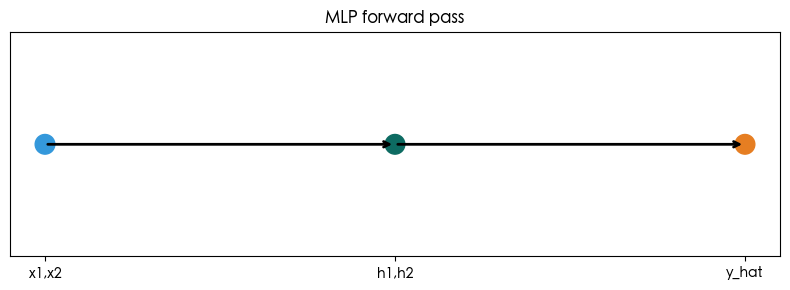

In [4]:
# 绘制这个小 MLP 的输入-隐藏层-输出结构。
plot_mlp_flow()